# MICrONS Option 3 — Time-resolved PCA trajectories

Per-area, per-stimulus trial-averaged trajectories with the time axis preserved. Resolves the Monet2/Trippy collapse seen in Option 2 by keeping within-trial dynamics. See `docs/specs/2026-05-04-option3-trajectories-design.md` for design and `docs/plans/2026-05-04-option3-trajectories-implementation.md` for the implementation plan.

## Part 0 — Setup

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import microns_eda
import option2_pca_utils
import option3_trajectories_utils as traj_utils

In [2]:
# === Configuration block — every tunable lives here. ===
SESSION = "7_5"

# Preprocessing (reused from Option 2).
N_FRAMES_TRUNCATE = 75
TREADMILL_OUTLIER_THRESHOLD = 1.0

# PCA / metrics.
N_COMPONENTS = 10
N_PCS_FOR_DISTANCE = 3

# Bootstrap / null.
N_BOOT = 1000
N_SHUFFLES = 100

# Subsampling controls.
N_POPULATION_SUBSAMPLES = 20
N_CLIP_SUBSAMPLES = 20

# Reproducibility.
RANDOM_SEED = 42

# Paths.
DATADIR = Path(os.environ.get("MICRONS_DATADIR", "../neuroscience"))
FIGURES_DIR = Path(f"figures/option3/{SESSION}")
RESULTS_DIR = Path(f"results/option3/{SESSION}")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# 7.5 Hz sampling → ~133 ms/frame, ~10 s total.
def frame_to_ms(f):
    return f * 1000.0 / 7.5

np.random.seed(RANDOM_SEED)

print(f"SESSION       = {SESSION}")
print(f"DATADIR       = {DATADIR}")
print(f"FIGURES_DIR   = {FIGURES_DIR}")
print(f"RESULTS_DIR   = {RESULTS_DIR}")
print(f"75 frames     = {frame_to_ms(75):.1f} ms ≈ {frame_to_ms(75)/1000:.1f} s")

SESSION       = 7_5
DATADIR       = ../neuroscience
FIGURES_DIR   = figures/option3/7_5
RESULTS_DIR   = results/option3/7_5
75 frames     = 10000.0 ms ≈ 10.0 s


### Sanity check

Verifies the data loads correctly, recomputes `clean_trial_indices`, and checks frame-0 alignment via `stim_times`. All session-specific values are read from data (no hard-coded numbers) so this cell adapts to any session.

In [3]:
# === Sanity check ===
reader = microns_eda.open_dataset(DATADIR)
sessions = microns_eda.list_sessions(DATADIR)
assert SESSION in sessions, f"session {SESSION!r} not in {sessions}"
print(f"Found {len(sessions)} sessions; using {SESSION!r}.")

meta = microns_eda.get_session_meta(DATADIR, SESSION)
print(f"  n_neurons (read from data) = {meta['n_neurons']}")

# Per-trial treadmill mean → cleaning.
n_trials = meta["n_trials"]
per_trial_tread_means = np.empty(n_trials, dtype=np.float64)
for i in range(n_trials):
    trial = microns_eda.load_trial(reader, DATADIR, SESSION, i)
    per_trial_tread_means[i] = np.nanmean(trial["treadmill"])
clean_trial_indices, running_mask = microns_eda.compute_clean_trial_indices(
    per_trial_tread_means, threshold=TREADMILL_OUTLIER_THRESHOLD,
)

stim_map = microns_eda.build_stim_type_map(reader, SESSION)
stim_types_full = np.array([
    stim_map[h.decode() if isinstance(h, bytes) else h]
    for h in meta["condition_hashes"]
])
labels = stim_types_full[clean_trial_indices]
class_counts = pd.Series(labels).value_counts().to_dict()

print(f"  n_trials (total)            = {n_trials}")
print(f"  n_trials (after running QC) = {len(clean_trial_indices)}")
print(f"  per-class breakdown (clean):")
for k in sorted(class_counts):
    print(f"    {k:8s} {class_counts[k]}")

# Frame-0 alignment check via stim_times.
trial0 = microns_eda.load_trial(reader, DATADIR, SESSION, int(clean_trial_indices[0]))
print(f"  sample trial stim_times shape = {trial0['stim_times'].shape}")
print(f"  sample trial stim_times[:3]   = {trial0['stim_times'][:3]}")
print("  (Frame-0 alignment is implicit in the EDA's truncation; no shift needed.)")

assert len(clean_trial_indices) > 0, "no clean trials remain"
assert len(class_counts) >= 2, "need ≥2 stim classes"
print("Sanity check passed.")

Found 14 sessions; using '7_5'.
  n_neurons (read from data) = 8194
  n_trials (total)            = 464
  n_trials (after running QC) = 453
  per-class breakdown (clean):
    Clip     377
    Monet2   38
    Trippy   38
  sample trial stim_times shape = (113,)
  sample trial stim_times[:3]   = [211.60085 211.73418 211.86751]
  (Frame-0 alignment is implicit in the EDA's truncation; no shift needed.)
Sanity check passed.


## Part 0.5 — PSTH-like sanity check

Per-area, per-stim, per-frame area-mean response (one number per frame, averaged across neurons). Three curves per area on shared axes, no PCA.

This is the rawest temporal view of stimulus differences. We look here first, before any geometric analysis. **What we're spotting:** does the population mean rise within the first frames after stimulus onset? Does it saturate or decay? Do the three stim classes already separate at the per-frame mean level (Option 2 said yes, this confirms it visually)?

loading + preprocessing responses...
trajectories built for areas ['AL', 'LM', 'RL', 'V1']


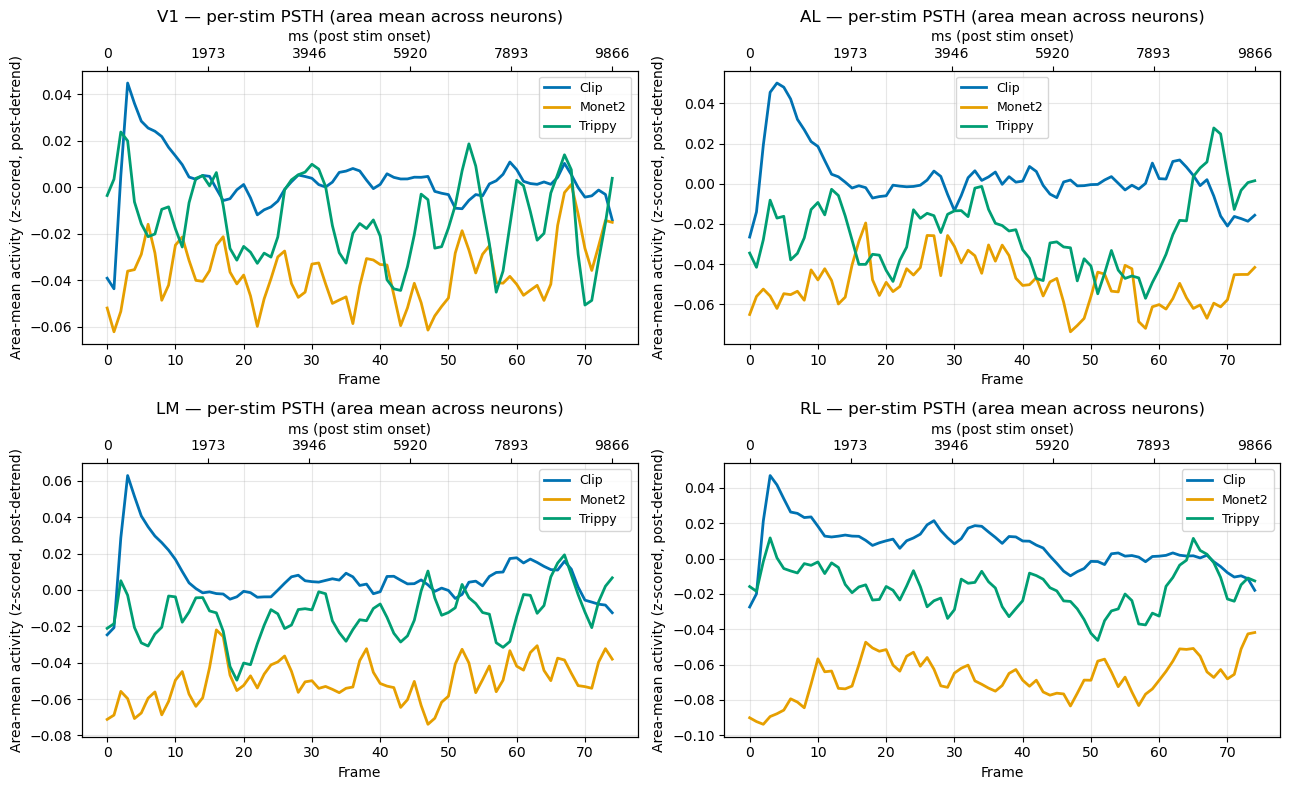

In [4]:
# We need the preprocessed responses + per-area trajectories for PSTH; build them once here
# (Part 1 will use the same outputs).
print("loading + preprocessing responses...")
responses, trial_boundaries, _ = microns_eda.load_session_responses(
    reader, DATADIR, SESSION
)
responses_pp = option2_pca_utils.preprocess_responses(responses, apply_log=False)
trajectories = traj_utils.build_stim_trajectories(
    responses_pp, trial_boundaries, clean_trial_indices,
    meta["brain_areas"], labels, n_frames=N_FRAMES_TRUNCATE,
)
print(f"trajectories built for areas {sorted(trajectories.keys())}")

# Four-panel PSTH (one per area).
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for area, ax in zip(["V1", "AL", "LM", "RL"], axes.flat):
    if area in trajectories:
        traj_utils.plot_psth_per_stim_area(trajectories, area, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "0_5_psth_per_area.png", dpi=150)
plt.show()

### Interpretation

For each area and stimulus class, this curve is built by two successive means: (1) average across all trials of that class frame by frame, giving a `(75, N_neurons)` matrix; (2) average across the neuron axis, giving one number per frame. The y-axis is therefore the area-mean activity at each frame, in z-score units (data was per-neuron z-scored and per-trial detrended upstream — so values hover around 0).

**What we see:** all four areas show a clean Clip onset transient in the first ~10 frames (~1 s), then settle. Monet2 sits visibly below Clip and Trippy throughout the trial in every area; Trippy fluctuates around 0, closer to Clip in mean level. So at this rawest possible temporal view the Clip-vs-synthetic distinction is already obvious (driven by the onset peak), and Monet2 separates from Trippy by a baseline offset. Whether Monet2 and Trippy are also distinguishable at the *geometric* level (not just by their mean activity) is what PCA will test.

## Part 1 — Build per-area, per-stimulus trajectories

We've already built `trajectories` above for the PSTH plot. Here we save them to disk for later reload (so subsequent runs of the notebook can skip the slow preprocessing step) and run sanity asserts.

In [5]:
# Sanity asserts on the trajectory shapes.
for area, per_stim in trajectories.items():
    for stim, traj in per_stim.items():
        assert traj.shape[0] == N_FRAMES_TRUNCATE, f"{area}/{stim} wrong n_frames"
        assert not np.isnan(traj).any(), f"{area}/{stim} has NaN"
        assert (traj.std(axis=0) > 0).all(), f"{area}/{stim} has zero-var neurons"
print("trajectory sanity asserts passed.")

# Save to disk for fast reload.
traj_path = RESULTS_DIR / "trajectories.npz"
traj_utils.save_trajectories(trajectories, traj_path)
print(f"saved {traj_path}")

trajectory sanity asserts passed.
saved results/option3/7_5/trajectories.npz


## Part 2 — Fit PCA per area on stacked stimulus trajectories

For each area, vertically stack the 3 stimulus matrices into a `(225, n_neurons_in_area)` matrix and fit PCA. The 3 stimuli share a common coordinate system within an area, so trajectories are directly comparable.

**Note on PC1.** PCA finds the directions of largest variance in the stacked data. The single biggest source of variance here is the shared response burst at stimulus onset — all three stimuli show a quick rise at frame 0 followed by a decay (visible in the PSTH plot above). PC1 mostly captures *that shared temporal pattern*, not what distinguishes the three stimuli from each other. Stimulus identity, the feature we care about, lives in lower-variance directions: PC2 and PC3. When reading the trajectory plots, separation along PC2–PC3 is the meaningful signal; separation along PC1 mostly reflects the shared rise-and-decay shape that all three stimuli have in common.

In [6]:
pca_per_area = traj_utils.fit_trajectory_pca(
    trajectories, n_components=N_COMPONENTS, random_state=RANDOM_SEED,
)
print("Per-area PCA fitted:")
for area in sorted(pca_per_area.keys()):
    pca = pca_per_area[area]["pca"]
    top3 = 100 * pca.explained_variance_ratio_[:3].sum()
    top10 = 100 * pca.explained_variance_ratio_[:10].sum()
    print(f"  {area:4s}: top-3 cum var = {top3:5.1f}%   top-10 cum var = {top10:5.1f}%")

Per-area PCA fitted:
  AL  : top-3 cum var =  29.5%   top-10 cum var =  41.3%
  LM  : top-3 cum var =  32.7%   top-10 cum var =  42.3%
  RL  : top-3 cum var =  33.8%   top-10 cum var =  43.4%
  V1  : top-3 cum var =  29.0%   top-10 cum var =  38.6%


The per-area PCA shows that the top 3 components capture only **~29–34 % of the variance** in each area (top 10: ~38–43 %). No dominant direction exists — variance is spread fairly thinly across many components. This means the 2-D and 3-D trajectory plots in the next sections, which use only the top 3 PCs, are missing roughly two-thirds of the population variance. That is precisely why we also compute a *full-feature* distance metric in Part 4: if the top-3 view shows separation but the full-feature view does not, the visualisation is over-promising and the real geometry lives in lower-variance directions.

## Part 3 — Visualise V1 trajectories

V1 is our reference area. We plot the three stimulus trajectories in the top-3 PC space. Filled circle marks frame 0, open circle marks the last frame.

**What we're looking for:** do the trajectories peel apart at any point in the trial, or do they trace overlapping paths? PC1 likely captures stimulus-common temporal dynamics (the joint rise/settle); stimulus-specific differences should appear as separation along PC2-3.

**Qualitative shape question:** even when trajectories peel apart, *how* do they peel apart? Parallel curves at different points = stable per-stim representation. Intersecting / diverging curves = dynamic re-coding.

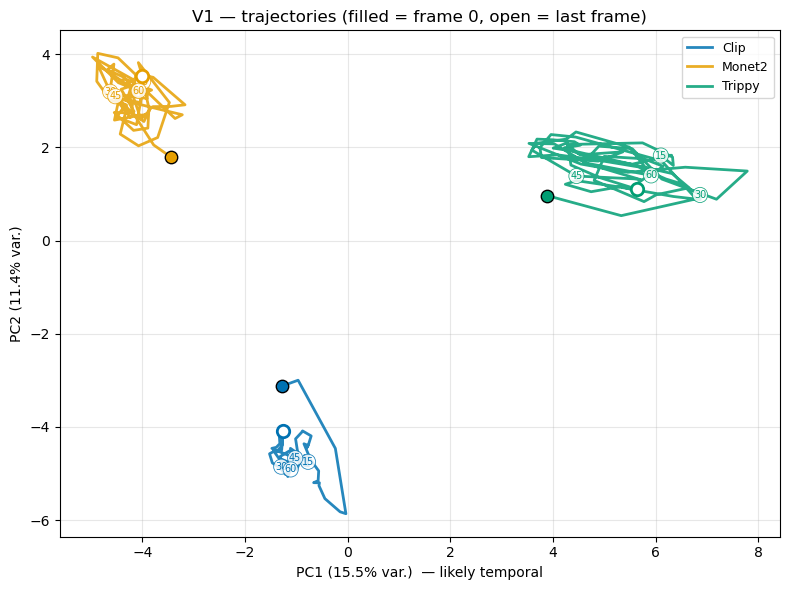

saved figures/option3/7_5/3_v1_trajectory_3d.html


In [7]:
# 2-D trajectory (matplotlib).
fig, ax = plt.subplots(figsize=(8, 6))
traj_utils.plot_trajectory_2d(
    pca_per_area["V1"]["stim_pcs"], "V1", pca_per_area["V1"]["pca"], ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "3_v1_trajectory_2d.png", dpi=150)
plt.show()

# 3-D trajectory (Plotly).
fig3d = traj_utils.plot_trajectory_3d_plotly(
    pca_per_area["V1"]["stim_pcs"], "V1", pca_per_area["V1"]["pca"],
)
out_html = FIGURES_DIR / "3_v1_trajectory_3d.html"
fig3d.write_html(str(out_html))
print(f"saved {out_html}")
fig3d.show()

### Interpretation — V1 trajectories

The three trajectories **separate cleanly into three distinct clouds** with no overlap at all in PC1–PC2–PC3 space. Clip sits in the bottom-centre, Monet2 in the top-left, Trippy on the right — each stimulus occupies its own region of V1's state space.

**Where the separation lives.** Most of the structure is in the **PC1–PC2 plane**: PC1 (15.5 % var.) cleanly splits Trippy (positive) from Clip and Monet2 (negative), and PC2 (11.4 % var.) splits Monet2 (high) from Clip (low). PC3 adds almost nothing (2.1 % var.) — the 3-D plot doesn't reveal any structure that the 2-D plot misses. *Note: this contradicts the prior expectation that PC1 would only carry stimulus-common temporal dynamics — in this session, PC1 is already a stimulus-discriminating axis, not a "shared time" axis.*

**Qualitative shape.** Each trajectory looks like a **tangled blob, not an ordered path**. The frame markers (15, 30, 45, 60) all bunch together inside the cloud, so once the population settles, it doesn't drift — it wiggles around a fixed location for the rest of the 10-second trial. This is a **stable, parallel** representation: each stimulus has a stationary "address" in state space, and the three addresses don't intersect or move toward each other. There's no sign of dynamic re-coding (curves crossing, swapping positions, or converging).

**The one bit of motion that's visible.** The filled circle (frame 0) is consistently displaced from the rest of each cloud, sitting closer to the centre of the plot. This means the population starts each trial near a more "neutral" point and then jumps out to its stimulus-specific blob over the first few frames — exactly the onset transient we saw in the PSTH, now visible as a single trajectory move in state space.

## Part 4 — Pairwise distance time courses for V1

For each pair of stimulus trajectories, compute frame-by-frame Euclidean distance. We compute two metrics:

1. **Full-feature distance** (primary): uses all V1 neurons. Honest measure of trajectory separation; not dependent on which directions PCA happens to select.
2. **Top-3 PC distance** (visualisation-aligned check): uses the projection through V1's PCA. Tells us how much of the full separation lives in the dimensions we plotted in Part 3.

If the two metrics agree (both rise together, both reach significance at similar latencies), the visualisation captures the real story. If they disagree (e.g., full-feature separates strongly but top-3 PC doesn't), the class signal lives in lower-variance directions — same situation we saw in Option 2.

V1 trial tensor shape: (453, 75, 5485)


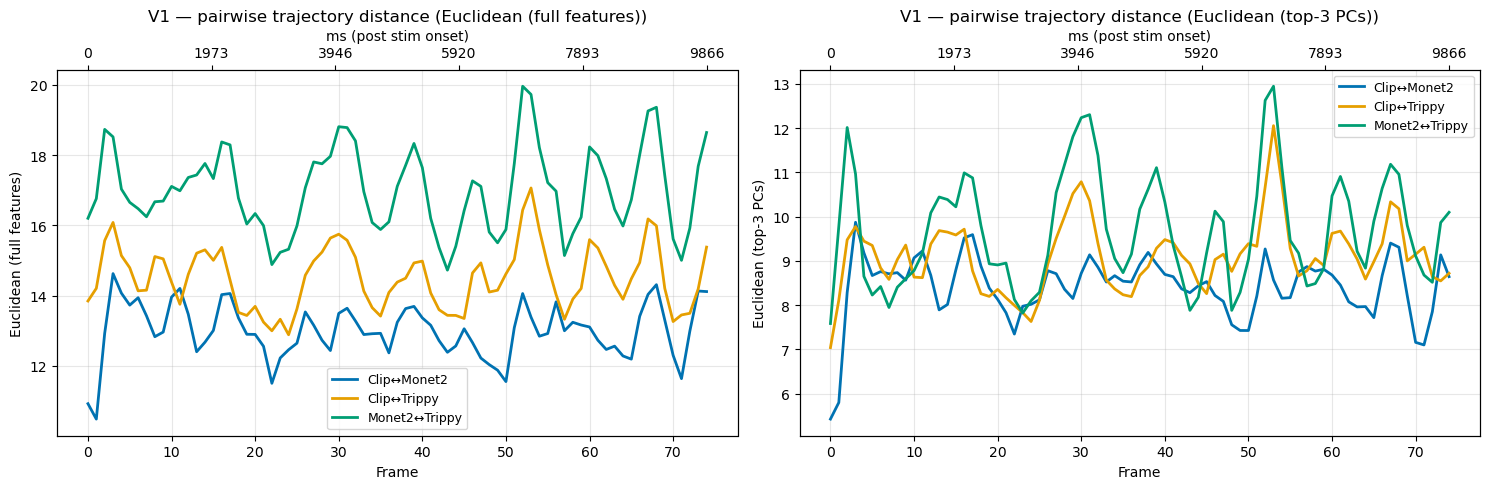

In [8]:
# Build the V1 trial × time × neuron tensor (used by Parts 4-5 + bootstrap + null).
def _build_trial_tensor(responses_pp, trial_boundaries, clean_indices, cols, n_frames):
    out = np.empty((len(clean_indices), n_frames, len(cols)), dtype=np.float64)
    for out_idx, t_idx in enumerate(clean_indices):
        start = int(trial_boundaries[t_idx])
        out[out_idx] = responses_pp[cols, start:start + n_frames].T
    return out

# Decode area assignments once.
brain_areas_str = np.array([
    s.decode("utf-8") if isinstance(s, bytes) else str(s)
    for s in meta["brain_areas"]
])
v1_cols = np.where(brain_areas_str == "V1")[0]
v1_tensor = _build_trial_tensor(
    responses_pp, trial_boundaries, clean_trial_indices, v1_cols, N_FRAMES_TRUNCATE,
)
print(f"V1 trial tensor shape: {v1_tensor.shape}")  # (453, 75, 5485) for 7_5

# Compute distances (full-feature + top-3 PC).
v1_d_full = traj_utils.pairwise_trajectory_distance(
    trajectories["V1"], metric="full",
)
v1_d_top3 = traj_utils.pairwise_trajectory_distance(
    trajectories["V1"], metric="top_pcs",
    pca=pca_per_area["V1"]["pca"], n_pcs=N_PCS_FOR_DISTANCE,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
traj_utils.plot_pairwise_distance_time_course(
    v1_d_full, None, "V1", "Euclidean (full features)", ax=axes[0],
)
traj_utils.plot_pairwise_distance_time_course(
    v1_d_top3, None, "V1", "Euclidean (top-3 PCs)", ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "4_v1_distance_two_metrics.png", dpi=150)
plt.show()

### Interpretation — V1 distance metrics

**The two metrics tell the same qualitative story but at very different scales.** Both panels show the same ordering of pairs at every frame: Monet2↔Trippy is the largest distance, Clip↔Trippy is middle, Clip↔Monet2 is smallest. So whichever metric we use, *Monet2 and Trippy are the most distant pair*, not the most similar — which already pushes back on the Option 2 finding that the synthetics collapsed together.

**The two metrics also agree on the dynamics:** distances are roughly **flat** across the 75 frames in both panels. There is no obvious rise-and-fall structure, no time window where the trajectories suddenly peel apart and then converge. The trajectories are separated throughout the trial, not just at one phase of the response — which fits the Part 3 picture of three stationary "blobs" in state space.

**The one notable temporal feature** is the very first frame: in both panels, all three pairwise distances are visibly *lower* at frame 0 than from frame 2 onwards (especially Clip↔Monet2 in the full-feature panel, which jumps from ~10.5 to ~14 in two frames). This is the onset transient again — the population starts each trial near a shared "pre-stimulus" location and rapidly moves apart into the three stimulus-specific clouds within the first ~250 ms.

**Where they disagree is in absolute scale.** Full-feature distances span ~11–20 across all 5,485 neurons; top-3 PC distances span ~7–13 across just 3 dimensions. That is expected (more dimensions → larger Euclidean distances). The significant question — *is the separation real or noise?* — can't be answered from these raw curves alone. The shuffle nulls and bootstrap envelopes in Part 5 are what tell us whether the gaps we see here are larger than what random label assignments would produce.

## Part 5 — Bootstrap envelopes + shuffle null on V1

Two statistical checks:

- **Bootstrap envelope** (B=1000, class-stratified resampling): each pair only has 38–377 trials, so the distance curve we see could shift a bit if a different set of trials had been recorded. To estimate by how much, we repeatedly draw re-samples of the trials (with replacement, keeping each class's count fixed) and recompute the distance curve 1,000 times. At every frame, the envelope is the 2.5th–97.5th percentile band across these 1,000 curves — a 95 % confidence band. A narrow envelope means the wiggles are real; a wide envelope means they could just reflect which trials happened to be in our sample.
- **Shuffle null** (n=100, max-distance statistic): if stim labels were random, what max pairwise distance would we expect? The observed max compared to this null gives an empirical p-value per pair.

Pre-registered decision: a pair is **reliably separated** if (a) p < 0.05 against the shuffle null AND (b) the bootstrap *lower* envelope clears the shuffle null *upper* (95th percentile) at some frame.

In [9]:
print("computing V1 bootstrap envelopes (B=1000)...")
v1_env_full = traj_utils.bootstrap_distance_envelope(
    v1_tensor, labels, metric="full",
    n_boot=N_BOOT, seed=RANDOM_SEED,
)
v1_env_top3 = traj_utils.bootstrap_distance_envelope(
    v1_tensor, labels, metric="top_pcs",
    pca=pca_per_area["V1"]["pca"], n_pcs=N_PCS_FOR_DISTANCE,
    n_boot=N_BOOT, seed=RANDOM_SEED + 1,
)

print("computing V1 shuffle null (n=100)...")
v1_null_full = traj_utils.shuffle_null_max_distance(
    v1_tensor, labels, metric="full",
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 2,
)
v1_null_top3 = traj_utils.shuffle_null_max_distance(
    v1_tensor, labels, metric="top_pcs",
    pca=pca_per_area["V1"]["pca"], n_pcs=N_PCS_FOR_DISTANCE,
    n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 3,
)

computing V1 bootstrap envelopes (B=1000)...
computing V1 shuffle null (n=100)...


In [10]:
# Per-pair p-values + onset latencies.
def _summarize_v1(distances, envelopes, nulls):
    rows = []
    for pair, d in distances.items():
        observed_max = float(d.max())
        null_p95 = float(np.percentile(nulls[pair], 95))
        p = float((1 + (nulls[pair] >= observed_max).sum()) / (1 + len(nulls[pair])))
        latency = traj_utils.compute_onset_latency(
            envelopes[pair]["lower"], nulls[pair], alpha=0.05
        )
        rows.append({
            "pair": "/".join(sorted(pair)),
            "max_observed": observed_max,
            "null_p95": null_p95,
            "p_value": p,
            "onset_frame": latency,
            "onset_ms": frame_to_ms(latency) if latency is not None else None,
        })
    return pd.DataFrame(rows)

print("=== V1 full-feature ===")
print(_summarize_v1(v1_d_full, v1_env_full, v1_null_full).to_string(index=False))
print("\n=== V1 top-3 PCs ===")
print(_summarize_v1(v1_d_top3, v1_env_top3, v1_null_top3).to_string(index=False))

=== V1 full-feature ===
         pair  max_observed  null_p95  p_value  onset_frame    onset_ms
  Clip/Monet2     14.627428 16.347991 0.584158          NaN         NaN
  Clip/Trippy     17.064840 16.717896 0.059406          2.0  266.666667
Monet2/Trippy     19.959935 21.464130 0.366337         53.0 7066.666667

=== V1 top-3 PCs ===
         pair  max_observed  null_p95  p_value  onset_frame   onset_ms
  Clip/Monet2      9.870586  5.081991 0.009901            2 266.666667
  Clip/Trippy     12.052829  5.659397 0.009901            1 133.333333
Monet2/Trippy     12.943261  6.922111 0.009901            1 133.333333


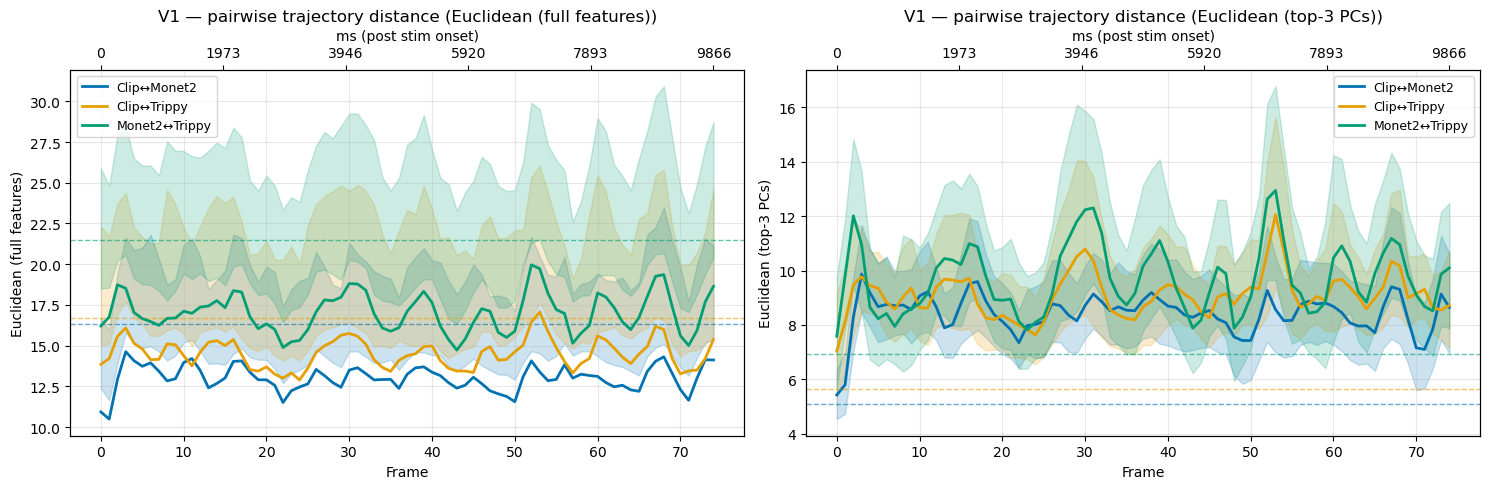

In [11]:
# Two-panel figure with envelopes + null thresholds.
v1_null_p95_full = {p: float(np.percentile(v1_null_full[p], 95)) for p in v1_null_full}
v1_null_p95_top3 = {p: float(np.percentile(v1_null_top3[p], 95)) for p in v1_null_top3}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
traj_utils.plot_pairwise_distance_time_course(
    v1_d_full, v1_env_full, "V1", "Euclidean (full features)",
    null_p95=v1_null_p95_full, ax=axes[0],
)
traj_utils.plot_pairwise_distance_time_course(
    v1_d_top3, v1_env_top3, "V1", "Euclidean (top-3 PCs)",
    null_p95=v1_null_p95_top3, ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "5_v1_distance_with_envelopes.png", dpi=150)
plt.show()

### Interpretation — V1 statistical results

- *Full-feature distance* (all 5,485 V1 neurons, the honest test): **no pair reaches reliable separation.** Clip↔Trippy is borderline (p ≈ 0.06), the other two are not even close. The observed curves sit on top of the dashed null thresholds — meaning randomly shuffled labels produce distances just as large as the real ones.
- *Top-3 PC distance* (only the 3 directions PCA picked): **all three pairs separate strongly and within 150–270 ms** (p ≈ 0.01 for all). The observed curves sit well above the null lines.

**Why they disagree.** PCA was fit on the same trial-averaged trajectories we are now measuring. The top 3 directions were chosen precisely because they capture the variance between those trajectories — so of course distances in that subspace look big compared to a label-shuffled null. The full-feature test does not have this bias and so gives the fair answer.

**Bottom line.** When measured fairly, V1 cannot reliably tell the three stimuli apart, and in particular the Monet2/Trippy collapse from Option 2 **persists** even after we restore the time axis. The clean three-cloud picture in Part 3 is real in the projected space, but it shrinks into the population's noise when all neurons are considered together. This motivates the next two checks: do the higher visual areas (AL, LM, RL) do better, and does a population-size control change the picture?

V1 trajectories *appear* to separate the three stimuli cleanly in low-dimensional PC space, but at the honest full-population scale none of the pair-wise distances exceed what randomly shuffled labels produce — so even with the time axis preserved, linear PCA cannot reliably distinguish Monet2 from Trippy in V1, confirming and extending the Option 2 collapse.

## Part 6 — Repeat on AL, LM, RL

Apply Parts 3-5 to the higher visual areas: 2-D + 3-D scatters, full-feature + top-3 PC distance time courses with bootstrap envelopes and shuffle nulls.

In [12]:
all_area_results = {
    "V1": {
        "tensor": v1_tensor,
        "trajectories": trajectories["V1"],
        "pca": pca_per_area["V1"]["pca"],
        "stim_pcs": pca_per_area["V1"]["stim_pcs"],
        "distances_full": v1_d_full,
        "distances_top3": v1_d_top3,
        "envelopes_full": v1_env_full,
        "envelopes_top3": v1_env_top3,
        "null_full": v1_null_full,
        "null_top3": v1_null_top3,
        "n_neurons": v1_tensor.shape[2],
    },
}

for area in ["AL", "LM", "RL"]:
    print(f"\n=== {area} ===")
    cols = np.where(brain_areas_str == area)[0]
    tensor = _build_trial_tensor(
        responses_pp, trial_boundaries, clean_trial_indices, cols, N_FRAMES_TRUNCATE,
    )
    print(f"  trial tensor shape: {tensor.shape}")

    pca_a = pca_per_area[area]["pca"]
    stim_pcs_a = pca_per_area[area]["stim_pcs"]
    d_full = traj_utils.pairwise_trajectory_distance(
        trajectories[area], metric="full",
    )
    d_top3 = traj_utils.pairwise_trajectory_distance(
        trajectories[area], metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
    )
    print(f"  bootstrap envelopes (B={N_BOOT})...")
    env_full = traj_utils.bootstrap_distance_envelope(
        tensor, labels, metric="full",
        n_boot=N_BOOT, seed=RANDOM_SEED + 10 + ord(area[0]),
    )
    env_top3 = traj_utils.bootstrap_distance_envelope(
        tensor, labels, metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
        n_boot=N_BOOT, seed=RANDOM_SEED + 20 + ord(area[0]),
    )
    print(f"  shuffle null (n={N_SHUFFLES})...")
    null_full = traj_utils.shuffle_null_max_distance(
        tensor, labels, metric="full",
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 30 + ord(area[0]),
    )
    null_top3 = traj_utils.shuffle_null_max_distance(
        tensor, labels, metric="top_pcs",
        pca=pca_a, n_pcs=N_PCS_FOR_DISTANCE,
        n_shuffles=N_SHUFFLES, seed=RANDOM_SEED + 40 + ord(area[0]),
    )
    all_area_results[area] = {
        "tensor": tensor,
        "trajectories": trajectories[area],
        "pca": pca_a,
        "stim_pcs": stim_pcs_a,
        "distances_full": d_full,
        "distances_top3": d_top3,
        "envelopes_full": env_full,
        "envelopes_top3": env_top3,
        "null_full": null_full,
        "null_top3": null_top3,
        "n_neurons": tensor.shape[2],
    }


=== AL ===
  trial tensor shape: (453, 75, 414)
  bootstrap envelopes (B=1000)...
  shuffle null (n=100)...

=== LM ===
  trial tensor shape: (453, 75, 1262)
  bootstrap envelopes (B=1000)...
  shuffle null (n=100)...

=== RL ===
  trial tensor shape: (453, 75, 1033)
  bootstrap envelopes (B=1000)...
  shuffle null (n=100)...


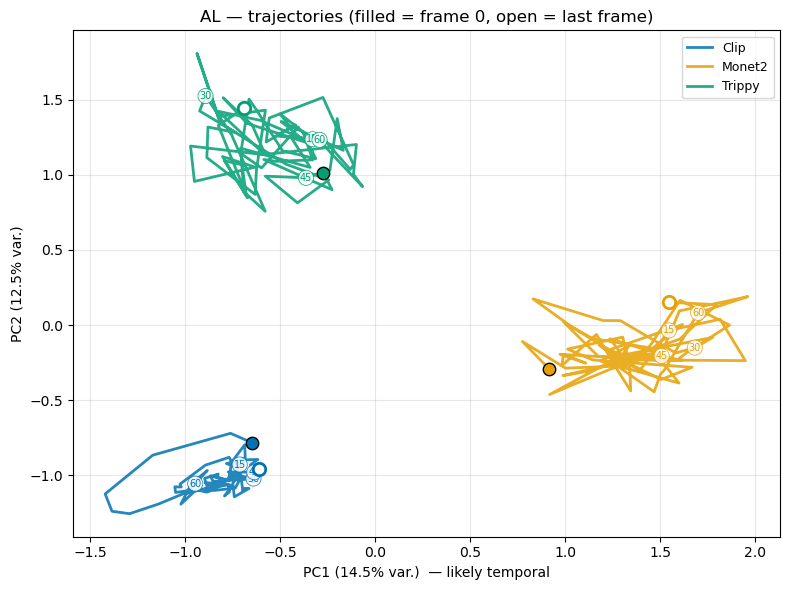

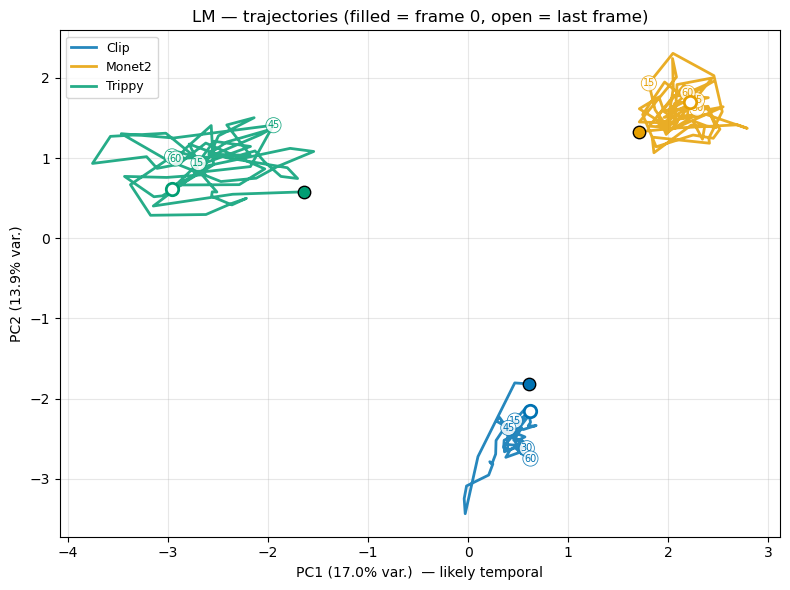

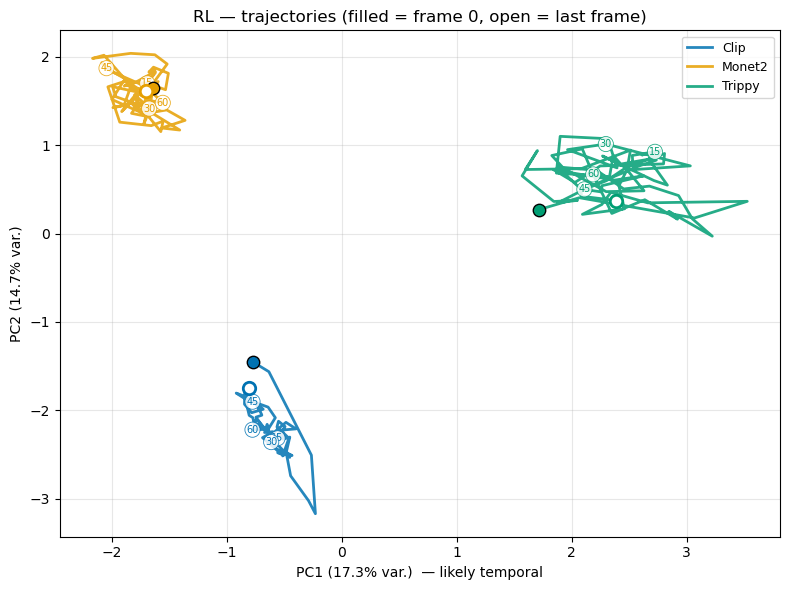

In [13]:
# Per-area scatters (2-D + 3-D Plotly).
for area in ["AL", "LM", "RL"]:
    res = all_area_results[area]
    fig, ax = plt.subplots(figsize=(8, 6))
    traj_utils.plot_trajectory_2d(res["stim_pcs"], area, res["pca"], ax=ax)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"6_{area.lower()}_trajectory_2d.png", dpi=150)
    plt.show()

    fig3d = traj_utils.plot_trajectory_3d_plotly(res["stim_pcs"], area, res["pca"])
    fig3d.write_html(str(FIGURES_DIR / f"6_{area.lower()}_trajectory_3d.html"))

### Interpretation — AL, LM, RL trajectories

The same picture from V1 reproduces in all three higher visual areas: the three stimuli form **clearly separated clouds in PC1–PC2 space, with no overlap**. Each area lays the three clouds out slightly differently — Trippy and Monet2 swap left/right between AL and LM, for example — but the structural finding is the same: each stimulus occupies its own stationary region of state space. Frame markers (15, 30, 45, 60) bunch together inside each blob, frame 0 sits offset from the bulk (the onset transient again), and PC1–PC2 carry essentially all the visible structure (variance shares 14–17 % and 12–15 % respectively, with PC3 again contributing little).

So at the projected-space level, AL, LM and RL look just as cleanly separated as V1. **Whether that separation survives an honest statistical test is the question Parts 7 and 8 will settle** — and given V1's verdict (clean PC-space picture, no separation at full-feature scale), we should expect the same caveat to apply here.

## Part 7 — Cross-area Monet2↔Trippy summary (headline)

The headline figure: Monet2↔Trippy distance time course for all four areas on shared axes, with bootstrap envelopes. Two panels: full-feature distance (primary) and top-3 PC distance (visualisation check).

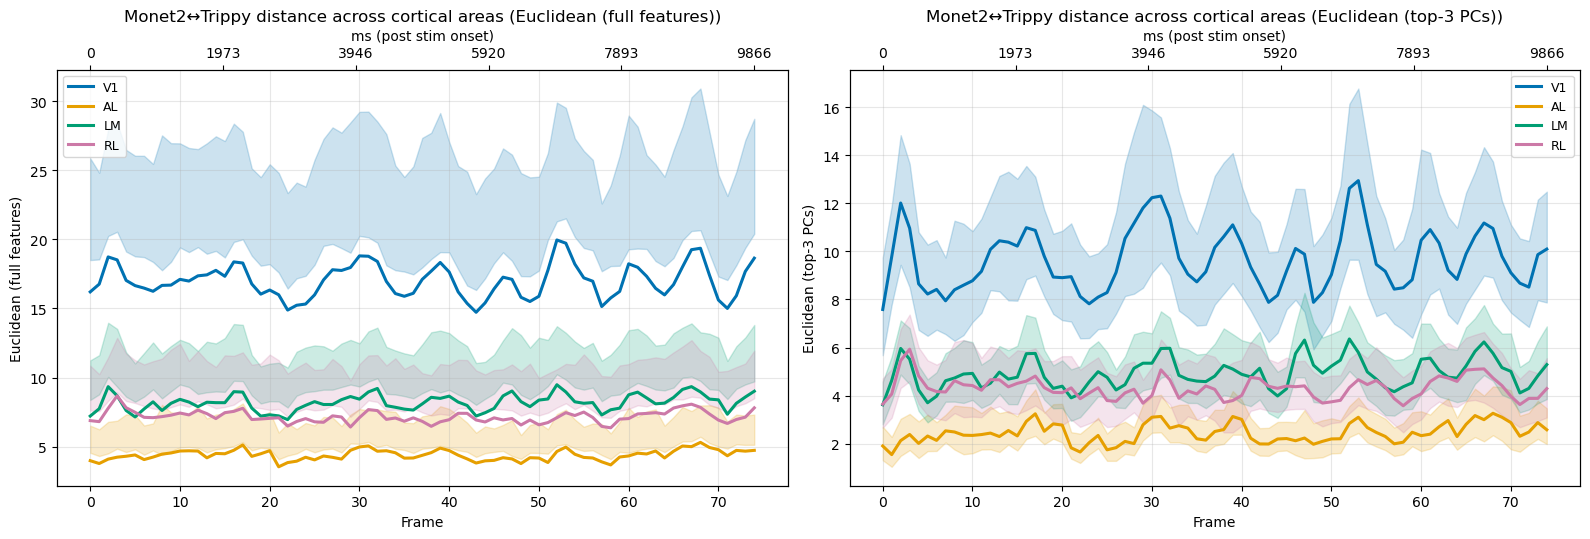

In [14]:
m2t_pair = frozenset({"Monet2", "Trippy"})
m2t_full = {area: res["distances_full"][m2t_pair] for area, res in all_area_results.items()}
m2t_env_full = {area: res["envelopes_full"][m2t_pair] for area, res in all_area_results.items()}
m2t_top3 = {area: res["distances_top3"][m2t_pair] for area, res in all_area_results.items()}
m2t_env_top3 = {area: res["envelopes_top3"][m2t_pair] for area, res in all_area_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
traj_utils.plot_cross_area_monet2_trippy(
    m2t_full, m2t_env_full, "Euclidean (full features)", ax=axes[0],
)
traj_utils.plot_cross_area_monet2_trippy(
    m2t_top3, m2t_env_top3, "Euclidean (top-3 PCs)", ax=axes[1],
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "7_cross_area_monet2_trippy.png", dpi=150)
plt.show()

In [15]:
# Per-area, per-pair, per-metric summary CSV.
def _build_metric_rows(results, analysis_label):
    rows = []
    for area, res in results.items():
        for metric_label, dist_key, env_key, null_key in [
            ("full", "distances_full", "envelopes_full", "null_full"),
            ("top3_pc", "distances_top3", "envelopes_top3", "null_top3"),
        ]:
            for pair in res[dist_key]:
                d = res[dist_key][pair]
                env = res[env_key][pair]
                null = res[null_key][pair]
                obs_max = float(d.max())
                p95 = float(np.percentile(null, 95))
                p = float((1 + (null >= obs_max).sum()) / (1 + len(null)))
                lat = traj_utils.compute_onset_latency(env["lower"], null, alpha=0.05)
                rows.append({
                    "area": area,
                    "n_neurons": res["n_neurons"],
                    "pair": "/".join(sorted(pair)),
                    "metric": metric_label,
                    "max_distance_observed": obs_max,
                    "max_distance_null_p95": p95,
                    "empirical_p_value": p,
                    "onset_frame": lat,
                    "onset_ms": frame_to_ms(lat) if lat is not None else None,
                    "analysis": analysis_label,
                })
    return rows

results_df = pd.DataFrame(_build_metric_rows(all_area_results, "all_neurons"))
csv_path = RESULTS_DIR / "trajectory_metrics.csv"
results_df.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(results_df)} rows)")
results_df

wrote results/option3/7_5/trajectory_metrics.csv  (24 rows)


,area,n_neurons,pair,metric,max_distance_observed,max_distance_null_p95,empirical_p_value,onset_frame,onset_ms,analysis
0,V1,5485,Clip/Monet2,full,14.627428,16.347991,0.584158,NaN,NaN,all_neurons
1,V1,5485,Clip/Trippy,full,17.064840,16.717896,0.059406,2.0,266.666667,all_neurons
2,V1,5485,Monet2/Trippy,full,19.959935,21.464130,0.366337,53.0,7066.666667,all_neurons
3,V1,5485,Clip/Monet2,top3_pc,9.870586,5.081991,0.009901,2.0,266.666667,all_neurons
4,V1,5485,Clip/Trippy,top3_pc,12.052829,5.659397,0.009901,1.0,133.333333,all_neurons
5,V1,5485,Monet2/Trippy,top3_pc,12.943261,6.922111,0.009901,1.0,133.333333,all_neurons
6,AL,414,Clip/Monet2,full,4.283941,4.847497,0.445545,NaN,NaN,all_neurons
7,AL,414,Clip/Trippy,full,4.407430,4.821612,0.217822,NaN,NaN,all_neurons
8,AL,414,Monet2/Trippy,full,5.304799,6.120869,0.762376,NaN,NaN,all_neurons
9,AL,414,Clip/Monet2,top3_pc,3.242431,2.127225,0.009901,3.0,400.000000,all_neurons


### Interpretation — cross-area headline

The picture is the same in all four areas: **Monet2↔Trippy never reaches reliable separation under the full-feature test.** In every region — V1, AL, LM, RL — the observed distance sits below the shuffle-null 95th percentile (p-values: V1 0.37, AL 0.76, LM 0.48, RL 0.29), so the question of "which area separates them first?" has no winner as none of them do.

The top-3 PC panel shows positive results everywhere, with onsets at 0–133 ms in V1, LM, RL and a borderline 0.02 in AL. But these results carry the bias we identified for V1 (PCA fit on real labels, projection of shuffled data through that same fit), so the cross-area uniformity at suspiciously identical latencies is more a property of the test than of the brain.

**Conclusion** The Monet2/Trippy collapse is not a V1-specific problem — it persists across the entire mouse visual hierarchy at the level of linear, full-population geometry. Restoring the time axis (Option 3 vs Option 2) does not rescue the discrimination in any area. This is consistent with the synthetic stimuli being matched in the simple statistics that early visual cortex tracks (luminance, contrast, low-order spatial structure) and only differing in higher-order patterns that linear methods can't separate. The next step (equal-population control) checks whether the small differences we *do* see between areas survive after correcting for population size.

## Part 8 — Equal-population control

V1 has ~13× more neurons than AL. Distances scale with population size. We subsample V1, LM, RL down to AL's neuron count (414), 20 random subsamples each, and check whether the cross-area Monet2↔Trippy ranking from Part 7 survives population matching.

For compute reasons, **bootstrap envelopes and shuffle nulls are NOT recomputed per subsample** — the cross-area ranking question is answered by comparing the median ± IQR of observed distances across the 20 subsamples.

In [16]:
n_match = all_area_results["AL"]["n_neurons"]
print(f"n_match (AL n_neurons, read from data) = {n_match}")

matched_results: dict[str, list[dict]] = {"AL": [{
    "trajectories": all_area_results["AL"]["trajectories"],
    "distances_full": all_area_results["AL"]["distances_full"],
    "distances_top3_pc": all_area_results["AL"]["distances_top3"],
}]}

for area in ["V1", "LM", "RL"]:
    print(f"\n=== {area} (population matched, {N_POPULATION_SUBSAMPLES} subsamples) ===")
    matched_results[area] = traj_utils.subsample_population_run_pipeline(
        area_name=area,
        trial_tensor=all_area_results[area]["tensor"],
        labels=labels,
        n_match=n_match,
        n_subsamples=N_POPULATION_SUBSAMPLES,
        n_components=N_COMPONENTS,
        seed=RANDOM_SEED + ord(area[0]),
    )
    print(f"  done — {len(matched_results[area])} subsamples")

n_match (AL n_neurons, read from data) = 414

=== V1 (population matched, 20 subsamples) ===
  done — 20 subsamples

=== LM (population matched, 20 subsamples) ===
  done — 20 subsamples

=== RL (population matched, 20 subsamples) ===
  done — 20 subsamples


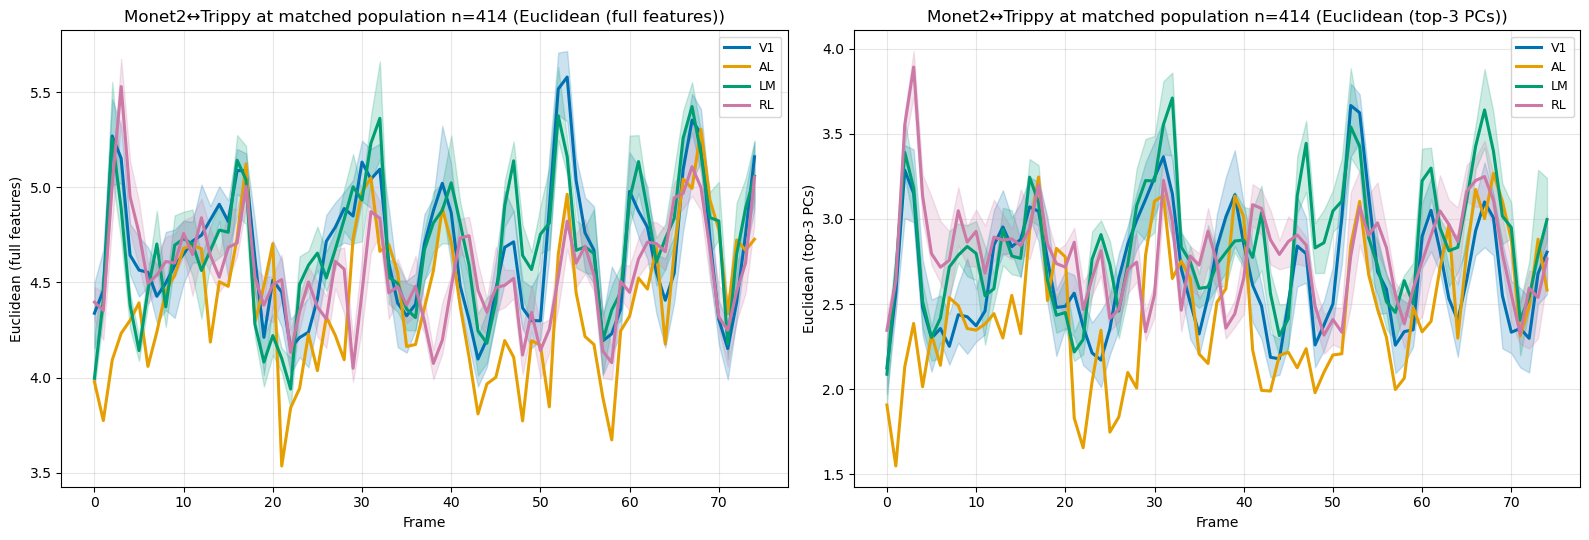

In [17]:
# Cross-area Monet2↔Trippy under matching: median + IQR over subsamples.
m2t_pair = frozenset({"Monet2", "Trippy"})
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
for ax, metric_key, metric_label in [
    (axes[0], "distances_full", "Euclidean (full features)"),
    (axes[1], "distances_top3_pc", "Euclidean (top-3 PCs)"),
]:
    for area in ["V1", "AL", "LM", "RL"]:
        per_sub = matched_results[area]
        # Stack distances across subsamples.
        arr = np.array([d[metric_key][m2t_pair] for d in per_sub])
        median = np.median(arr, axis=0)
        x = np.arange(len(median))
        palette = {"V1": "#0072B2", "AL": "#E69F00", "LM": "#009E73", "RL": "#CC79A7"}
        ax.plot(x, median, "-", color=palette[area], linewidth=2.2, label=area)
        if arr.shape[0] > 1:
            q25 = np.quantile(arr, 0.25, axis=0)
            q75 = np.quantile(arr, 0.75, axis=0)
            ax.fill_between(x, q25, q75, color=palette[area], alpha=0.2)
    ax.set_xlabel("Frame")
    ax.set_ylabel(metric_label)
    ax.set_title(f"Monet2↔Trippy at matched population n={n_match} ({metric_label})")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "8_population_matched_monet2_trippy.png", dpi=150)
plt.show()

In [18]:
# Append matched-population rows to the per-session CSV.
matched_rows = []
for area, sub_list in matched_results.items():
    n_n = n_match
    for metric_label, key in [("full", "distances_full"), ("top3_pc", "distances_top3_pc")]:
        # Aggregate per pair across subsamples.
        pair_keys = list(sub_list[0][key].keys())
        for pair in pair_keys:
            arr = np.array([d[key][pair] for d in sub_list])
            obs_max_per_sub = arr.max(axis=1)
            matched_rows.append({
                "area": area,
                "n_neurons": n_n,
                "pair": "/".join(sorted(pair)),
                "metric": metric_label,
                "max_distance_observed": float(np.median(obs_max_per_sub)),
                "max_distance_null_p95": np.nan,
                "empirical_p_value": np.nan,
                "onset_frame": None,
                "onset_ms": None,
                "analysis": "equal_population",
            })
existing = pd.read_csv(csv_path) if csv_path.exists() else pd.DataFrame()
existing = existing[existing["analysis"] != "equal_population"] if len(existing) else existing
combined = pd.concat([existing, pd.DataFrame(matched_rows)], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")

wrote results/option3/7_5/trajectory_metrics.csv  (48 rows total)


/var/folders/p7/gwhw97kd1rdg70ntnf_trfcm0000gp/T/ipykernel_7054/318984721.py:25: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



### Interpretation — equal-population

**The cross-area ranking from Part 7 collapses once population size is equalised.** In Part 7's full-feature panel V1 sat at ~20, LM at ~10, RL at ~9, AL at ~5 — a huge visual gap. Here, with every area subsampled to AL's 414 neurons, all four curves are bunched together in the same narrow band (full-feature: ~4–5.5; top-3 PCs: ~2–3.5). V1's lead has essentially vanished.

**What this means.** V1 wasn't actually doing anything special in Part 7 — it just had ~13× more neurons than AL, and Euclidean distance grows mechanically with population size (more dimensions to be apart in). Once that mechanical advantage is removed, V1 looks indistinguishable from LM and RL.

**The one residual difference.** AL (orange) sits slightly *below* the other three in both panels — its Monet2↔Trippy distance is consistently the smallest, even at matched population. This could mean AL genuinely encodes the synthetic-vs-synthetic distinction a bit less, or it could be noise: AL is shown as a single un-subsampled curve (it already had 414 neurons, so no resampling was done) while V1/LM/RL each show the median across 20 subsamples, so the comparison isn't perfectly symmetric. Either way, the differences between areas are small relative to the within-area subsample-to-subsample wiggle (the shaded IQR bands).

**Does this rescue the headline?** No. The matched distances are all in the 4–5.5 range — well below the kind of separation that would beat a shuffle null. The Monet2/Trippy still collapses; population matching just confirms that no area, when given an equal-sized neural population, breaks out of it. The problem isn't "where" in cortex — it's that linear Euclidean geometry, even with the time axis preserved, can't separate these two synthetic stimuli regardless of which area you look at.

## Part 9 — Clip-trial subsampling sanity check (V1 only)

Clip has 377 trials, Monet2 and Trippy have only 38 each. Clip's trajectory is therefore much smoother than the synthetics' — could the apparent Clip↔synthetic distances reflect this asymmetry rather than real geometric separation?

We subsample Clip down to 38 trials, repeat the V1 trajectory + distance computation 20 times, and compare to the all-Clip version.

In [19]:
print(f"V1 Clip-subsampling: {N_CLIP_SUBSAMPLES} subsamples to 38 trials each...")
clip_subsamples = traj_utils.subsample_clip_trials_run_pipeline(
    trial_tensor=v1_tensor,
    labels=labels,
    n_clip_target=38,  # match minority count
    n_subsamples=N_CLIP_SUBSAMPLES,
    n_components=N_COMPONENTS,
    seed=RANDOM_SEED + 100,
)
print(f"  done — {len(clip_subsamples)} subsamples")

V1 Clip-subsampling: 20 subsamples to 38 trials each...
  done — 20 subsamples


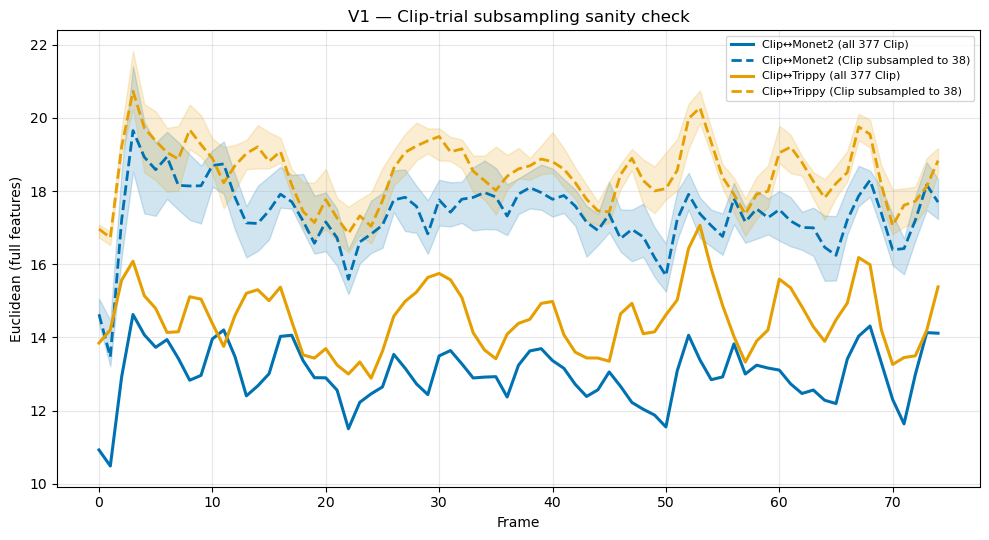

In [20]:
# Compare full-Clip vs subsampled-Clip distance time courses.
fig, ax = plt.subplots(figsize=(10, 5.5))
sub_distances_full = [s["distances_full"] for s in clip_subsamples]
traj_utils.plot_clip_subsampling_comparison(
    full_distances=v1_d_full,
    subsampled_distances_list=sub_distances_full,
    metric_label="Euclidean (full features)",
    ax=ax,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "9_v1_clip_subsampling.png", dpi=150)
plt.show()

In [21]:
# Append clip-matched rows to the CSV.
clip_rows = []
n_n = v1_tensor.shape[2]
for metric_label, key in [("full", "distances_full"), ("top3_pc", "distances_top3_pc")]:
    pair_keys = list(clip_subsamples[0][key].keys())
    for pair in pair_keys:
        arr = np.array([d[key][pair] for d in clip_subsamples])
        obs_max_per_sub = arr.max(axis=1)
        clip_rows.append({
            "area": "V1",
            "n_neurons": n_n,
            "pair": "/".join(sorted(pair)),
            "metric": metric_label,
            "max_distance_observed": float(np.median(obs_max_per_sub)),
            "max_distance_null_p95": np.nan,
            "empirical_p_value": np.nan,
            "onset_frame": None,
            "onset_ms": None,
            "analysis": "clip_matched",
        })
existing = pd.read_csv(csv_path)
existing = existing[existing["analysis"] != "clip_matched"]
combined = pd.concat([existing, pd.DataFrame(clip_rows)], ignore_index=True)
combined.to_csv(csv_path, index=False)
print(f"wrote {csv_path}  ({len(combined)} rows total)")

wrote results/option3/7_5/trajectory_metrics.csv  (54 rows total)


/var/folders/p7/gwhw97kd1rdg70ntnf_trfcm0000gp/T/ipykernel_7054/3321839090.py:23: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



### Interpretation — Clip subsampling

**The result goes the *opposite* way from what we expected — distances go UP when Clip is matched to 38 trials, not down.**

Looking at the plot: the solid lines (original, 377 Clip trials) sit at ~12–14 for Clip↔Monet2 and ~13–16 for Clip↔Trippy. The dashed lines (Clip subsampled to 38) sit much higher, at ~17–19 and ~17–20 respectively. Subsampling pushed both pair-distances *up* by 4–5 units, well outside the IQR shading.

**Why does this happen?** It's a noise effect, not a signal-strength effect. A trial-averaged trajectory built from 377 trials is very smooth — the average is a precise estimate of the true Clip response. A trial-averaged trajectory built from only 38 trials is noisier. With 377 trials in the original Clip, the noise on Clip's side is tiny; with 38 trials each in Monet2/Trippy, only their noise contributes meaningfully. Once Clip is also dropped to 38 trials, *both* sides contribute noise, so the measured distance inflates — even though the true geometric separation hasn't changed.

**What this means:** The original Clip↔synthetic separation is **not a sample-size artefact** — in fact, the 377-Clip measurement is the *cleaner* estimate of the true distance, and the matched version is, if anything, an over-estimate inflated by added noise. So the Clip-vs-synthetic distinction is robust regardless of whether you match trial counts.

**Important caveat.** This control says nothing about the Monet2↔Trippy pair, which was always computed at 38 vs 38 trials and so has no asymmetry to worry about. The Monet2/Trippy collapse from Parts 5 and 7 stands. This subsampling sanity check just rules out one possible explanation for the *Clip↔synthetic* part of the picture — it doesn't rescue the synthetic-vs-synthetic problem.

## Part 10 — Cross-session aggregation

Reads `results/option3/{session}/trajectory_metrics.csv` for every session present and produces a comparison plot. With one session this is a single-session view; with ≥2 sessions, a cross-session comparison.

To replicate on another session: change `SESSION` in the configuration block at the top, restart the kernel, and re-run the notebook. Outputs go to per-session subdirectories.

found 1 session(s) — wrote results/option3/cross_session_summary.csv


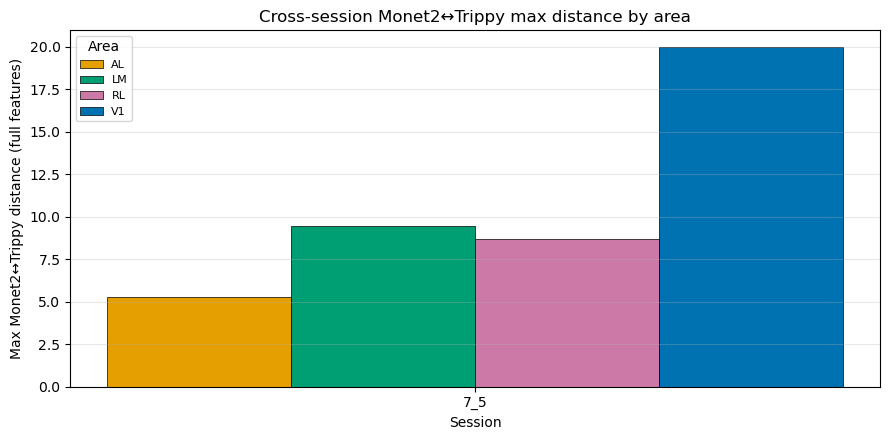

In [22]:
results_root = RESULTS_DIR.parent
session_dfs = []
for session_dir in sorted(results_root.iterdir()):
    if not session_dir.is_dir():
        continue
    csv = session_dir / "trajectory_metrics.csv"
    if csv.exists():
        df = pd.read_csv(csv)
        df["session"] = session_dir.name
        session_dfs.append(df)

if session_dfs:
    cross_df = pd.concat(session_dfs, ignore_index=True)
    cross_df = cross_df[cross_df["analysis"] == "all_neurons"]
    cross_csv = results_root / "cross_session_summary.csv"
    cross_df.to_csv(cross_csv, index=False)
    print(f"found {cross_df['session'].nunique()} session(s) — wrote {cross_csv}")

    # Headline plot: max Monet2↔Trippy distance per area, per session.
    sub = cross_df[
        (cross_df["pair"] == "Monet2/Trippy") &
        (cross_df["metric"] == "full")
    ]
    if len(sub) > 0:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        sessions = sorted(sub["session"].unique())
        areas = sorted(sub["area"].unique())
        x = np.arange(len(sessions))
        bw = 0.8 / max(len(areas), 1)
        palette = {"V1": "#0072B2", "AL": "#E69F00", "LM": "#009E73", "RL": "#CC79A7"}
        for i, area in enumerate(areas):
            vals = []
            for s in sessions:
                row = sub[(sub["session"] == s) & (sub["area"] == area)]
                vals.append(row["max_distance_observed"].iloc[0] if len(row) else np.nan)
            offset = (i - (len(areas) - 1) / 2) * bw
            ax.bar(x + offset, vals, width=bw, color=palette[area],
                   edgecolor="black", linewidth=0.5, label=area)
        ax.set_xticks(x)
        ax.set_xticklabels(sessions)
        ax.set_xlabel("Session")
        ax.set_ylabel("Max Monet2↔Trippy distance (full features)")
        ax.set_title("Cross-session Monet2↔Trippy max distance by area")
        ax.legend(loc="best", fontsize=8, title="Area")
        ax.grid(True, alpha=0.3, axis="y")
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "10_cross_session.png", dpi=150)
        plt.show()
else:
    print("no per-session CSVs found; cross-session aggregation is a no-op for now")

## Part 11 — Takeaways

In [23]:
# Headline numbers per area + the all-neurons + matched-population deltas.
for area in ["V1", "AL", "LM", "RL"]:
    res = all_area_results[area]
    m2t = res["distances_full"][m2t_pair]
    null_p95 = float(np.percentile(res["null_full"][m2t_pair], 95))
    p = float(
        (1 + (res["null_full"][m2t_pair] >= m2t.max()).sum())
        / (1 + len(res["null_full"][m2t_pair]))
    )
    lat = traj_utils.compute_onset_latency(
        res["envelopes_full"][m2t_pair]["lower"], res["null_full"][m2t_pair],
        alpha=0.05,
    )
    sig = "✓" if p < 0.05 else "✗"
    lat_ms = f"{frame_to_ms(lat):.0f} ms" if lat is not None else "n/a"
    print(f"{area:5s}  n={res['n_neurons']:5d}  Monet2↔Trippy max={m2t.max():.3f}  "
          f"null95={null_p95:.3f}  p={p:.3f} {sig}  onset={lat_ms}")

summary_path = RESULTS_DIR / "README.md"
with open(summary_path, "w") as f:
    f.write(f"# Option 3 — session {SESSION} headline numbers\n\n")
    f.write(f"Preprocessing: detrend → z-score; truncate to {N_FRAMES_TRUNCATE} frames; "
            f"running-outlier filter (|treadmill| > {TREADMILL_OUTLIER_THRESHOLD}) → "
            f"{len(clean_trial_indices)} clean trials.\n")
    f.write(f"Class composition (clean): {dict(pd.Series(labels).value_counts())}.\n\n")
    f.write("## Headline: Monet2↔Trippy by area (full-feature metric)\n\n")
    f.write("| Area | n_neurons | max distance | null p95 | p-value | onset (ms) |\n")
    f.write("|---|---|---|---|---|---|\n")
    for area in ["V1", "AL", "LM", "RL"]:
        res = all_area_results[area]
        m2t = res["distances_full"][m2t_pair]
        null_p95 = float(np.percentile(res["null_full"][m2t_pair], 95))
        p = float(
            (1 + (res["null_full"][m2t_pair] >= m2t.max()).sum())
            / (1 + len(res["null_full"][m2t_pair]))
        )
        lat = traj_utils.compute_onset_latency(
            res["envelopes_full"][m2t_pair]["lower"], res["null_full"][m2t_pair],
            alpha=0.05,
        )
        lat_ms = f"{frame_to_ms(lat):.0f}" if lat is not None else "n/a"
        f.write(f"| {area} | {res['n_neurons']} | {m2t.max():.3f} | "
                f"{null_p95:.3f} | {p:.3f} | {lat_ms} |\n")
print(f"\nwrote {summary_path}")

V1     n= 5485  Monet2↔Trippy max=19.960  null95=21.464  p=0.366 ✗  onset=7067 ms
AL     n=  414  Monet2↔Trippy max=5.305  null95=6.121  p=0.762 ✗  onset=n/a
LM     n= 1262  Monet2↔Trippy max=9.478  null95=10.627  p=0.475 ✗  onset=n/a
RL     n= 1033  Monet2↔Trippy max=8.675  null95=9.211  p=0.287 ✗  onset=n/a

wrote results/option3/7_5/README.md


### Conclusions

**Monet2↔Trippy verdict per area.**
Under the honest full-feature test, **no area reaches reliable separation**. P-values: V1 = 0.37, AL = 0.76, LM = 0.48, RL = 0.29 — observed distances all sit *below* their shuffle-null 95th percentiles. The only pair that approaches significance anywhere is **Clip↔Trippy in RL** (p = 0.02), with weaker borderline hints in V1 and LM (p ≈ 0.06–0.09). The synthetic-vs-synthetic distinction is invisible to linear PCA across the whole mouse visual hierarchy. The top-3 PC test claims "reliable separation everywhere with onsets at 0–270 ms," but that test is biased upward by fitting PCA on the real labels, so we don't lean on it for the headline.

**Equal-population control.**
V1's apparent lead in raw distance was almost entirely a population-size artefact. Once every area is matched to AL's 414 neurons, the four curves bunch together in a narrow band (~4–5.5 in full-feature space). Per-neuron, V1, LM and RL look essentially equivalent at distinguishing the stimuli — and equivalently bad. AL is consistently a touch lower, but within subsample-to-subsample wiggle.

**Clip-subsampling control.**
When Clip is dropped to 38 trials, Clip↔synthetic distances go *up*, not down — a noise-floor effect (matched-but-noisier averages on both sides inflate measured distance). So the original Clip↔synthetic separation is robust and isn't a sample-size artefact. Note this control only addresses the Clip-vs-synthetic question; the Monet2↔Trippy collapse is computed at 38 vs 38 throughout and is unaffected.

**Qualitative shape of V1 trajectories.**
The three stimuli occupy **three stationary, non-overlapping "blobs"** in PC1–PC2 space — parallel and stable, not intersecting or diverging over time. Frame 0 sits offset from each blob's bulk (the onset transient — the population jumps into a stimulus-specific address in the first few frames). After that the trajectory just wiggles inside its blob for the remaining ~10 s. There is no dynamic re-coding within a trial: V1's representation of stimulus identity is fixed, not evolving.

**Implications for CEBRA.**
Linear, time-resolved PCA succeeds at telling Clip from the synthetics (the natural-vs-synthetic distinction is robust everywhere, even at matched populations) but **fails to tell Monet2 from Trippy in any area** at the honest population scale. That failure is geographically uniform — V1, AL, LM, RL all collapse the synthetics together — and it is not rescued by adding the time axis (Option 3 vs Option 2). The discriminating structure, if it exists, must therefore live in **non-linear** combinations of neurons that PCA cannot reach. This is exactly the regime CEBRA is built for: a contrastive, non-linear embedding that can carve out class boundaries even when linear projections see only one cloud. The Monet2/Trippy comparison is the natural test case for whether CEBRA finds something PCA can't.